# Final Project Notebook

**Project Title:** [Your Project Title]  
**Team Members:** Kelly Zhou, Paula Martinez, Sankaranarayanan Krishnamoorthy  
**Course:** DX703, Spring 2026  
**Date:** 04-27-2026  

This notebook presents our final machine learning pipeline, including finalized preprocessing, final model retraining, and evaluation on a held-out test set.

# A.1: Setup and Context

## A.1.1 Project Overview

Summary of Milestones 1 and 2:

A short Markdown overview describing major steps we took previosuly, including:

- Data cleaning and preprocessing
- Feature engineering or augmentation strategies
- Early model experiments in Milestone 2 and what we learned from them.

Final preprocessing pipeline:

Include all finalized code for:

- Loading the dataset
- Cleaning steps (text normalization, image transforms, etc.)
- Preprocessing (tokenization, resizing, normalization, augmentation, etc.)
- This is your opportunity to refine or simplify any parts of your earlier pipeline based on what you learned in Milestone 2.




**REPONSE:**

## A.1.1 Project Overview

This project focuses on building a machine learning model to classify news headlines from the HuffPost dataset into predefined categories. The goal is to develop a clean and reproducible pipeline that processes raw text data, trains a model, and evaluates its performance on unseen data.

In Milestone 1, we performed initial EDA and preprocessing. This included combining the headline and short description fields, cleaning the text, removing duplicates and very short entries, and encoding category labels. We also examined the class distribution and identified challenges such as class imbalance and overlapping categories.

In Milestone 2, we experimented with multiple model approaches, including simpler baselines and more advanced architectures. These experiments helped us evaluate different training strategies and performance metrics, particularly macro-F1, which is well-suited for imbalanced multiclass problems. Based on these results, we selected a pretrained DistilBERT model as our final architecture due to its strong performance and ability to capture semantic patterns in text.

This notebook displays the finalized pipeline, including preprocessing, retraining of the selected model, and evaluation on a held-out test set. The focus is on clarity, reproducibility, and providing a complete end-to-end implementation of the modeling workflow.

## A.1.2 Imports and Global Settings

Import packages, set random seeds, define constants, and configure any plotting or runtime settings.

In [1]:
# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Hugging Face + PyTorch
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader

# sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
MODEL_DIR = "models"
OUTPUT_DIR = "outputs"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Constants
MODEL_NAME = "distilbert-base-uncased" #used in milestone 2; expanding upon this model
MAX_LENGTH = 128
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
EPOCHS = 3
PATIENCE = 2
WEIGHT_DECAY = 0.01

Using device: cuda


## A.1.3 Data Loading

Explain where the dataset comes from and how the train, validation, and test data are loaded.

In [2]:
#load HuffPost dataset from Hugging Face
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


## A.1.4 Final Preprocessing Pipeline

Describe the final preprocessing pipeline you decided to keep after Milestones 1 and 2.

Include things like:
- text cleaning / normalization
- tokenization or vectorization
- image resizing / normalization / augmentation
- label encoding
- helper functions for preprocessing


The preprocessing pipeline used in this notebook is based on the approach developed in Milestone 2, with edits to improve clarity and reproducibility. Experimental steps and unused branches were removed, and the final pipeline reflects only the transformations used for the selected model.

In [3]:
#combine headline and short description into one text field
def combine_text(example):
    headline = example.get("headline") or ""
    description = example.get("short_description") or ""
    return headline + " [SEP] " + description

texts = [combine_text(ex) for ex in huff_all]
labels = [ex["category"] for ex in huff_all]

huffpost_df = pd.DataFrame({
    "text": texts,
    "category": labels
})

print("Initial shape:", huffpost_df.shape)
huffpost_df.head()

Initial shape: (200853, 2)


,text,category
0,There Were 2 Mass Shootings In Texas Last Week...,CRIME
1,Will Smith Joins Diplo And Nicky Jam For The 2...,ENTERTAINMENT
2,Hugh Grant Marries For The First Time At Age 5...,ENTERTAINMENT
3,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,ENTERTAINMENT
4,Julianna Margulies Uses Donald Trump Poop Bags...,ENTERTAINMENT


In [4]:
huffpost_df["text"] = huffpost_df["text"].str.lower().str.strip()

#remove very short rows
huffpost_df = huffpost_df[huffpost_df["text"].str.len() > 20]

#remove duplicates
huffpost_df = huffpost_df.drop_duplicates(subset="text").reset_index(drop=True)

print("Shape after cleaning:", huffpost_df.shape)

Shape after cleaning: (200185, 2)


In [5]:
#encode labels
labels_sorted = sorted(huffpost_df["category"].unique())
label_to_id = {label: i for i, label in enumerate(labels_sorted)}
id_to_label = {i: label for label, i in label_to_id.items()}

huffpost_df["label"] = huffpost_df["category"].map(label_to_id)

print("Number of classes:", len(label_to_id))
print(huffpost_df[["category", "label"]].head())

Number of classes: 41
        category  label
0          CRIME      6
1  ENTERTAINMENT     10
2  ENTERTAINMENT     10
3  ENTERTAINMENT     10
4  ENTERTAINMENT     10


In [6]:
#stratified train/validation/test split: 80/10/10
train_df, temp_df = train_test_split(
    huffpost_df,
    test_size=0.2,
    stratify=huffpost_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 160148
Validation size: 20018
Test size: 20019


In [7]:
#initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [8]:
#convert pandas dfs to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

#apply tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

#reformat for PyTorch
columns_to_return = ["input_ids", "attention_mask", "label"]
train_dataset.set_format(type="torch", columns=columns_to_return)
val_dataset.set_format(type="torch", columns=columns_to_return)
test_dataset.set_format(type="torch", columns=columns_to_return)

Map:   0%|          | 0/160148 [00:00<?, ? examples/s]

Map:   0%|          | 0/20018 [00:00<?, ? examples/s]

Map:   0%|          | 0/20019 [00:00<?, ? examples/s]

## A.1.5 Processed Data / Sanity Checks

Use this section to confirm the preprocessing worked correctly.

In [9]:
#create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Number of train batches:", len(train_loader))
print("Number of val batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of train batches: 5005
Number of val batches: 626
Number of test batches: 626


In [10]:
#inspect class distribution in train split
train_class_counts = train_df["category"].value_counts()
print(train_class_counts.head(10))

category
POLITICS          26165
WELLNESS          14257
ENTERTAINMENT     12838
TRAVEL             7901
STYLE & BEAUTY     7609
PARENTING          6919
HEALTHY LIVING     5334
QUEER VOICES       5048
FOOD & DRINK       4980
BUSINESS           4742
Name: count, dtype: int64


In [11]:
#check one processed batch
sample_batch = next(iter(train_loader))
print("input_ids shape:", sample_batch["input_ids"].shape)
print("attention_mask shape:", sample_batch["attention_mask"].shape)
print("label shape:", sample_batch["label"].shape)

input_ids shape: torch.Size([32, 128])
attention_mask shape: torch.Size([32, 128])
label shape: torch.Size([32])


# A.2: Model Selection and Retraining

## A.2.1 Final Model Choice

State which final model you selected and why.

Mention:
- the architecture/model family
- why it was chosen based on Milestone 2 results
- what metric(s) informed your choice


The final model selected is a pretrained DistilBERT classifier. This model was chosen based on validation performance in Milestone 2, where it outperformed simpler baselines and custom models in terms of macro-F1.

## A.2.2 Architecture Definition

Briefly explain the architecture before the code cell below.

In [12]:
#compute class weights from training labels
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

#load final pretrained model
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_to_id)
).to(device)

print(model.config)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10",
    "11": "LABEL_11",
    "12": "LABEL_12",
    "13": "LABEL_13",
    "14": "LABEL_14",
    "15": "LABEL_15",
    "16": "LABEL_16",
    "17": "LABEL_17",
    "18": "LABEL_18",
    "19": "LABEL_19",
    "20": "LABEL_20",
    "21": "LABEL_21",
    "22": "LABEL_22",
    "23": "LABEL_23",
    "24": "LABEL_24",
    "25": "LABEL_25",
    "26": "LABEL_26",
    "27": "LABEL_27",
    "28": "LABEL_28",
    "29": "LABEL_29",
    "30": "LABEL_30",
    "31": "LABEL_31",
    "32": "LABEL_32",
    "33": "LABEL_33",
    "34

## A.2.3 Hyperparameters

Document your final hyperparameters here in Markdown, then define them in code below.

Suggested items:
- o Learning rate and LR schedulers
- Batch size
- Number of epochs
- Dropout rates
- Weight decay / L2 regularization (if any)
- Anything else…


The hyperparameters used for training were selected based on standard practices for transformer fine-tuning and prior experimentation. A small learning rate was used to preserve pretrained representations, and batch size and number of epochs were chosen to balance performance and training time.

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

## A.2.4 Optimization Strategy

Show the optimizer configuration and describe why it is appropriate (e.g., Adam for stability, SGD + momentum, etc.).

**RESPONSE:**

For the final model, we used the AdamW optimizer, which is a standard choice for transformer fine-tuning because it provides stable optimization and works well with pretrained language models. We used a small learning rate appropriate for DistilBERT fine-tuning and applied class-weighted cross-entropy loss to help address class imbalance in the HuffPost dataset.

A learning rate scheduler was also included to gradually reduce the learning rate when validation performance stops improving. This helps improve training stability and can reduce overfitting.

In [14]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)

# Loss function with class weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",         #bc we want to maximize validation macro-F1
    factor=0.5,
    patience=1)

print("Optimizer, loss, and scheduler configured.")

Optimizer, loss, and scheduler configured.


## A.2.5 Callbacks / Training Controls

Include any callbacks used during training (early stopping, checkpointing, LR scheduler).

Briefly explain how these helped prevent overfitting or improve training stability.


**RESPONSE:**

To improve training stability and reduce overfitting, we usd three training controls:

1. **Early stopping**: stops training if validation macro-F1 does not improve for a fixed number of epochs.
2. **Checkpointing**: saves the best-performing model based on validation macro-F1.
3. **Learning rate scheduling**: reduces the learning rate when validation performance plateaus.

These choices help ensure that the final saved model reflects the strongest validation performance rather than simply the final epoch.

In [15]:
#training control settings
early_stopping_patience = PATIENCE
best_model_path = os.path.join(MODEL_DIR, "best_distilbert_huffpost.pt")

best_val_macro_f1 = 0.0
epochs_without_improvement = 0

print("Best model will be saved to:", best_model_path)

Best model will be saved to: models/best_distilbert_huffpost.pt


## A.2.6 Training / Retraining Loop

Run the full training loop using:
- The entire training set
- A held-out validation split
- A separate test set reserved for final evaluation

In [16]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, accuracy, macro_f1, weighted_f1

In [17]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, accuracy, macro_f1, weighted_f1, all_preds, all_labels

In [18]:
#history dictionary for plotting later in A.3
history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_macro_f1": [],
    "train_weighted_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "val_weighted_f1": []
}

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)

    #train
    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    #validate
    val_loss, val_acc, val_macro_f1, val_weighted_f1, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    #update scheduler using validation macro-F1
    scheduler.step(val_macro_f1)

    #save history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["train_macro_f1"].append(train_macro_f1)
    history["train_weighted_f1"].append(train_weighted_f1)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_weighted_f1"].append(val_weighted_f1)

    #print metrics
    print(f"Train Loss:       {train_loss:.4f}")
    print(f"Train Accuracy:   {train_acc:.4f}")
    print(f"Train Macro-F1:   {train_macro_f1:.4f}")
    print(f"Train Weighted-F1:{train_weighted_f1:.4f}")

    print(f"Val Loss:         {val_loss:.4f}")
    print(f"Val Accuracy:     {val_acc:.4f}")
    print(f"Val Macro-F1:     {val_macro_f1:.4f}")
    print(f"Val Weighted-F1:  {val_weighted_f1:.4f}")

    #checkpointing + early stopping
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print("Saved new best model.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping triggered.")
        break

total_training_time = time.time() - start_time
print(f"\nTraining complete in {total_training_time:.2f} seconds.")


Epoch 1/3
--------------------------------------------------
Train Loss:       1.6192
Train Accuracy:   0.5616
Train Macro-F1:   0.4897
Train Weighted-F1:0.5747
Val Loss:         1.2421
Val Accuracy:     0.6297
Val Macro-F1:     0.5645
Val Weighted-F1:  0.6378
Saved new best model.

Epoch 2/3
--------------------------------------------------
Train Loss:       1.0568
Train Accuracy:   0.6578
Train Macro-F1:   0.6087
Train Weighted-F1:0.6675
Val Loss:         1.1700
Val Accuracy:     0.6547
Val Macro-F1:     0.5938
Val Weighted-F1:  0.6659
Saved new best model.

Epoch 3/3
--------------------------------------------------
Train Loss:       0.7999
Train Accuracy:   0.7132
Train Macro-F1:   0.6821
Train Weighted-F1:0.7191
Val Loss:         1.1921
Val Accuracy:     0.6418
Val Macro-F1:     0.5866
Val Weighted-F1:  0.6546
No improvement for 1 epoch(s).

Training complete in 1210.48 seconds.


## A.2.7 Training Summary

Summarize the outcome of retraining.

**RESPONSE:**

This retraining procedure used the finalized preprocessing pipeline and the selected DistilBERT architecture on the HuffPost dataset. Model selection during training was based on validation macro-F1, which is appropriate for this imbalanced multiclass problem. The best model checkpoint saved during this process will be used in the final evaluation section on the held-out test set.

In [19]:
print("Best validation macro-F1:", round(best_val_macro_f1, 4))
print("Best model path:", best_model_path)
print("Training epochs completed:", len(history["train_loss"]))
print("Total training time (seconds):", round(total_training_time, 2))

Best validation macro-F1: 0.5938
Best model path: models/best_distilbert_huffpost.pt
Training epochs completed: 3
Total training time (seconds): 1210.48


# A.3: Evaluation and Visualization

## A.3.1 Evaluation Strategy

Describe:
- how the validation split was used
- how the test set was kept separate
- which evaluation metrics are appropriate for your dataset
    - HuffPost: macro-F1, weighted-F1, accuracy, etc.

## A.3.2 Final Test Evaluation

Use this section to generate final predictions on the test set and compute the final test metrics.

In [20]:
#reload best saved model before final test eval
best_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_to_id)
).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

print("Best model loaded from:", best_model_path)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best model loaded from: models/best_distilbert_huffpost.pt


In [21]:
#eval. on the held-out test set
test_loss, test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate(
    best_model, test_loader, criterion, device)

print("Final Test Metrics")
print("-" * 30)
print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Test Macro-F1:    {test_macro_f1:.4f}")
print(f"Test Weighted-F1: {test_weighted_f1:.4f}")

Final Test Metrics
------------------------------
Test Loss:        1.1795
Test Accuracy:    0.6498
Test Macro-F1:    0.5869
Test Weighted-F1: 0.6622


## A.3.3 Training vs Validation Curves



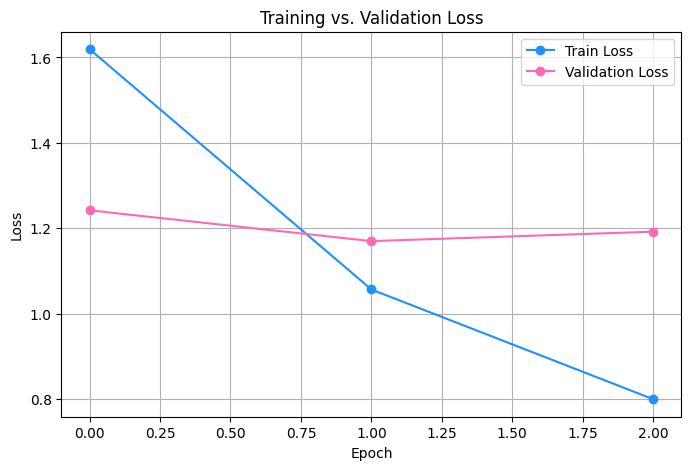

In [22]:
#training vs. validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], marker="o", label="Train Loss", color='dodgerblue')
plt.plot(history["val_loss"], marker="o", label="Validation Loss", color='hotpink')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

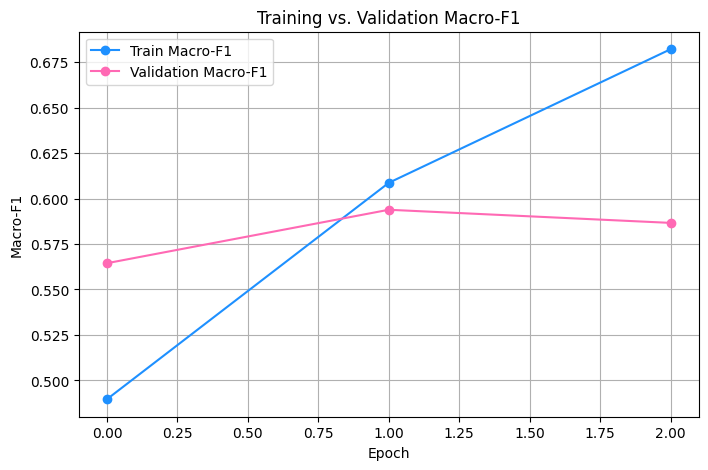

In [23]:
#rraining vs validation macro-F1
plt.figure(figsize=(8, 5))
plt.plot(history["train_macro_f1"], marker="o", label="Train Macro-F1", color='dodgerblue')
plt.plot(history["val_macro_f1"], marker="o", label="Validation Macro-F1", color='hotpink')
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training vs. Validation Macro-F1")
plt.legend()
plt.grid(True)
plt.show()

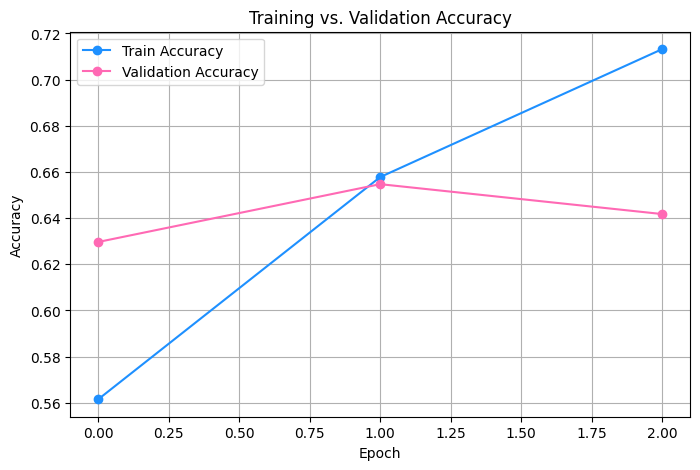

In [24]:
#training vs validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], marker="o", label="Train Accuracy", color='dodgerblue')
plt.plot(history["val_accuracy"], marker="o", label="Validation Accuracy", color='hotpink')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## A.3.4 Confusion Matrix


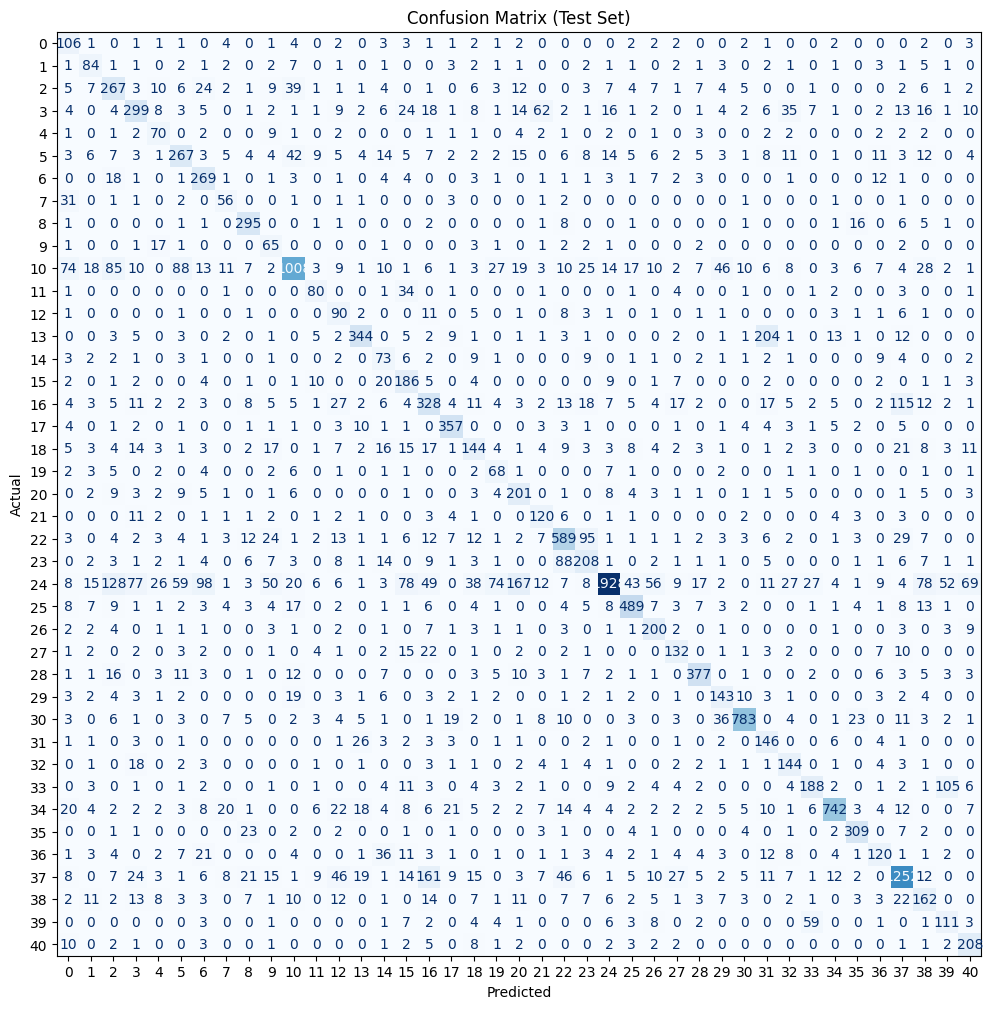

In [25]:
#confusion matrix on the test set
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## A.3.5 Dataset-Specific Metrics

Include any additional metrics appropriate for your dataset.

Examples:
- HuffPost: macro-F1, weighted-F1, class-frequency table

For the HuffPost dataset, macro-F1 and weighted-F1 are especially informative because the dataset contains many classes with uneven frequencies. In addition to overall accuracy, the classification report provides precision, recall, and F1-score for each category.

In [26]:
report = classification_report(
    test_labels,
    test_preds,
    target_names=[id_to_label[i] for i in range(len(id_to_label))],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.head()

,precision,recall,f1-score,support
ARTS,0.331250,0.706667,0.451064,150.0
ARTS & CULTURE,0.459016,0.626866,0.529968,134.0
BLACK VOICES,0.440594,0.590708,0.504726,452.0
BUSINESS,0.573896,0.504216,0.536804,593.0
COLLEGE,0.411765,0.614035,0.492958,114.0


In [27]:
#overall summary rows
report_df.loc[["accuracy", "macro avg", "weighted avg"]]

,precision,recall,f1-score,support
accuracy,0.649783,0.649783,0.649783,0.649783
macro avg,0.560787,0.647346,0.586914,20019.000000
weighted avg,0.703972,0.649783,0.662246,20019.000000


In [28]:
#lowest-performing classes by F1
per_class_df = report_df.iloc[:-3].copy()  # removes accuracy/macro avg/weighted avg
lowest_f1 = per_class_df.sort_values("f1-score").head(10)
lowest_f1[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
GOOD NEWS,0.294355,0.525180,0.377261,139.0
EDUCATION,0.278970,0.650000,0.390390,100.0
LATINO VOICES,0.314815,0.601770,0.413374,113.0
FIFTY,0.312500,0.647482,0.421546,139.0
IMPACT,0.448598,0.416185,0.431784,346.0
TASTE,0.314655,0.698565,0.433878,209.0
WORLD NEWS,0.377551,0.511521,0.434442,217.0
WOMEN,0.402985,0.476471,0.436658,340.0
ARTS,0.331250,0.706667,0.451064,150.0
HEALTHY LIVING,0.460028,0.491754,0.475362,667.0


In [29]:
#highest-performing classes by F1
highest_f1 = per_class_df.sort_values("f1-score", ascending=False).head(10)
highest_f1[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
STYLE & BEAUTY,0.921176,0.823344,0.869517,951.0
WEDDINGS,0.813158,0.846575,0.829530,365.0
TRAVEL,0.905983,0.751012,0.821251,988.0
HOME & LIVING,0.786344,0.858173,0.820690,416.0
SPORTS,0.816017,0.772541,0.793684,488.0
DIVORCE,0.730198,0.862573,0.790885,342.0
QUEER VOICES,0.793831,0.774960,0.784282,631.0
WELLNESS,0.791403,0.702581,0.744352,1782.0
POLITICS,0.931401,0.589422,0.721962,3271.0
ENTERTAINMENT,0.828266,0.628037,0.714387,1605.0


In [30]:
#class frequency table for the training set
class_frequency_df = train_df["category"].value_counts().reset_index()
class_frequency_df.columns = ["category", "train_count"]
class_frequency_df.head(10)

,category,train_count
0,POLITICS,26165
1,WELLNESS,14257
2,ENTERTAINMENT,12838
3,TRAVEL,7901
4,STYLE & BEAUTY,7609
5,PARENTING,6919
6,HEALTHY LIVING,5334
7,QUEER VOICES,5048
8,FOOD & DRINK,4980
9,BUSINESS,4742


## A.3.6 Final Test Metrics
Include a clean printout of the final test performance (accuracy/per-class metrics/etc.).

Write here discussing:
- strongest and weakest classes
- confusion patterns
- possible overfitting / underfitting
- what the final metrics suggest about task difficulty

The final DistilBERT model achieved a test accuracy of 0.6498 and a macro-F1 score of 0.5869. Because the HuffPost dataset is highly imbalanced, the macro-F1 score provides a more meaningful evaluation than accuracy alone, as it reflects performance across frequent and infrequent categories. The weighted-F1 score of 0.6622 being closer to accuracy further suggets that the model performs better on more common classes.

The training and validation curves show that the model was able to learn stable and meaningful patterns from the data. While training performance is slightly higher than validation performance, suggesting the presence of some overfitting, the gap is relatively small. This indicates that the model generalizes reasonably well to unseen data.

Analysis of the confusion matrix and per-class metrics reveals that performance varies significantly across categories. Some classes, such as BUSINESS, show relatively balanced precision and recall, indicating that the model can distinguish these categories effectively. Other categories such as ARTS exhibit high recall but low precision, suggesting that the model frequently predicts these labels even when incorrect. This pattern indicates that certain categories more ambiguous language, making them more prone to misclassification.

Categories with overlapping themes (such as politics, business, and culture-related topics) are more likely to be confused with one another. This reflects the inherent difficulty of the task, as short news headlines often lack enough context to clearly distinguish between similar categories.

Overall, the pretrained DistilBERT model demonstrates strong performance for this task, effectively capturing semantic patterns in text. However, the results highlight the challenges posed by class imbalance and semantic overlap, which limit performance on less frequent or more ambiguous categories.